<a href="https://colab.research.google.com/github/Bavesh-08/heartfailure-prediction-model/blob/main/Heart_Failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel("/content/heart failure prediction dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:

print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

In [ ]:

df = df.dropna()
df.shape


(1025, 14)

In [ ]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

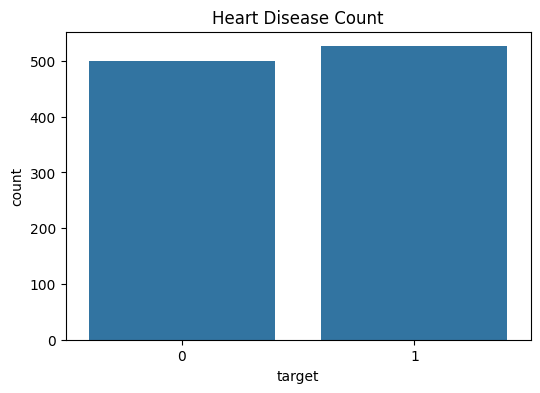

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Count")
plt.show()



In [ ]:

X = df.drop('target', axis=1)
y = df['target']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

results

{'Logistic Regression': 0.7951219512195122,
 'Random Forest': 0.9853658536585366,
 'SVM': 0.6829268292682927}

In [ ]:

for model, acc in results.items():
    print(f"{model}: {acc * 100:.2f}%")


Logistic Regression: 79.51%
Random Forest: 98.54%
SVM: 68.29%


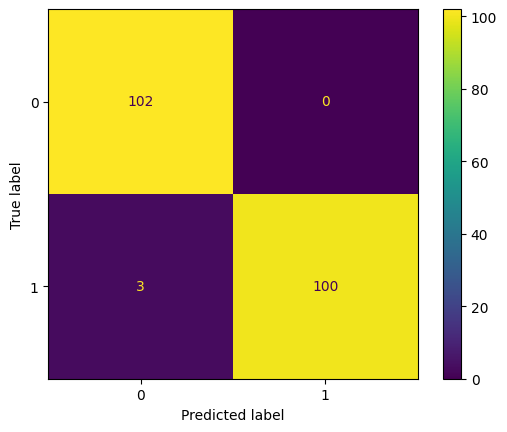

No Heart Disease (Actual 0): 102
Heart Disease (Actual 1): 103

Detailed:
True Negative (TN): 102
False Positive (FP): 0
False Negative (FN): 3
True Positive (TP): 100


In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("No Heart Disease (Actual 0):", tn + fp)
print("Heart Disease (Actual 1):", fn + tp)

print("\nDetailed:")
print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)


In [ ]:
import numpy as np

total_disease = np.sum(y_pred == 1)
total_no_disease = np.sum(y_pred == 0)

print("Total predicted with heart failure (disease):", total_disease)
print("Total predicted without heart failure (no disease):", total_no_disease)


Total predicted with heart failure (disease): 100
Total predicted without heart failure (no disease): 105


In [ ]:
print("\n=== Enter Patient Details ===")
age = float(input("Age: "))
sex = input("Sex (M/F): ").upper()
chest_pain = input("ChestPainType (ATA/NAP/ASY/TA): ").upper()
rest_bp = float(input("RestingBP: "))
cholesterol = float(input("Cholesterol: "))
fasting_bs = int(input("FastingBS (0/1): "))
rest_ecg = input("RestingECG (Normal/ST/LVH): ").upper()
max_hr = float(input("MaxHR: "))
ex_angina = input("ExerciseAngina (Y/N): ").upper()
oldpeak = float(input("Oldpeak: "))
st_slope = input("ST_Slope (Up/Flat/Down): ").upper()
ca = int(input("Number of major vessels (ca, 0-4): "))
thal = int(input("Thal (0-3, e.g., 0=normal, 1=fixed defect, 2=reversible defect, 3=normal): "))


=== Enter Patient Details ===
Age: 18
Sex (M/F): m
ChestPainType (ATA/NAP/ASY/TA): ta
RestingBP: 250
Cholesterol: 250
FastingBS (0/1): 1
RestingECG (Normal/ST/LVH): st
MaxHR: 200
ExerciseAngina (Y/N): n
Oldpeak: 200
ST_Slope (Up/Flat/Down): up
Number of major vessels (ca, 0-4): 3
Thal (0-3, e.g., 0=normal, 1=fixed defect, 2=reversible defect, 3=normal): 2


In [ ]:
import pandas as pd

# Mappings for categorical features based on common conventions for heart disease datasets
# and observed unique values in the dataframe `df`.
sex_map = {'M': 1, 'F': 0}
# Assuming: ASY=0, ATA=1, NAP=2, TA=3 (common in UCI Heart Disease dataset)
cp_map = {'ASY': 0, 'ATA': 1, 'NAP': 2, 'TA': 3}
# Assuming: Normal=0, ST=1, LVH=2
restecg_map = {'NORMAL': 0, 'ST': 1, 'LVH': 2}
exang_map = {'Y': 1, 'N': 0}
# Assuming: Down=0, Flat=1, Up=2
slope_map = {'DOWN': 0, 'FLAT': 1, 'UP': 2}

# Create the DataFrame with correct column names and numerical encodings
input_patient = pd.DataFrame({
    'age': [age],
    'sex': [sex_map.get(sex, -1)], # Use .get() for safety against invalid input
    'cp': [cp_map.get(chest_pain, -1)],
    'trestbps': [rest_bp],
    'chol': [cholesterol],
    'fbs': [fasting_bs],
    'restecg': [restecg_map.get(rest_ecg, -1)],
    'thalach': [max_hr],
    'exang': [exang_map.get(ex_angina, -1)],
    'oldpeak': [oldpeak],
    'slope': [slope_map.get(st_slope, -1)],
    'ca': [ca],
    'thal': [thal]
}, index=[0])

# Check for any -1 values in mapped categorical features, which would indicate invalid input
if any(input_patient[['sex', 'cp', 'restecg', 'exang', 'slope']].iloc[0] == -1):
    print("Warning: One or more categorical inputs were invalid and mapped to -1. This might lead to incorrect predictions.")

In [ ]:
result = clf.predict(input_patient)[0]
prob = clf.predict_proba(input_patient)[0]

print("\n=== RESULTS ===")
print("Prediction:", "HEART DISEASE DETECTED!" if result == 1 else "No Heart Disease")
print(f"Heart Disease Probability: {prob[1]*100:.1f}%")
print(f"No Disease Probability: {prob[0]*100:.1f}%")


=== RESULTS ===
Prediction: HEART DISEASE DETECTED!
Heart Disease Probability: 59.0%
No Disease Probability: 41.0%


SAVING THE TRAINED MODEL

In [ ]:
import pickle

In [ ]:
filename='heart_failure_model.sav'
pickle.dump(clf,open(filename,'wb'))